In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../data/reservoir_info.csv')

In [3]:
df.head(3)

,Reservoir Name,Initial Reservoir Pressure (PSI),Bubble Point Pressure (PSI),Current Average Reservoir Pressure (PSI),Solution Gas-Oil-Ratio (SCF/BBL),Formation Volume Factor (RB/STB)
0,ACHI,"3,500","3,300","2,700",800,1.20
1,KEMA,"4,200","4,000","3,900",600,1.45
2,MAKO,"3,500","3,500","3,000",500,1.15


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 6 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Reservoir Name                            5 non-null      object 
 1   Initial Reservoir Pressure (PSI)          5 non-null      object 
 2   Bubble Point Pressure (PSI)               5 non-null      object 
 3   Current Average Reservoir Pressure (PSI)  5 non-null      object 
 4   Solution Gas-Oil-Ratio (SCF/BBL)          5 non-null      object 
 5   Formation Volume Factor (RB/STB)          5 non-null      float64
dtypes: float64(1), object(5)
memory usage: 372.0+ bytes


In [5]:
cols = df.columns.drop('Reservoir Name').to_list()
cols

['Initial Reservoir Pressure (PSI)',
 'Bubble Point Pressure (PSI)',
 'Current Average Reservoir Pressure (PSI)',
 'Solution Gas-Oil-Ratio (SCF/BBL)',
 'Formation Volume Factor (RB/STB)']

In [6]:
# Function to clean numeric columns (handles commas, spaces, etc.)
def clean_numeric_column(series):
    return (series.astype(str)
            .str.replace(',', '')  # Remove commas
            .str.replace(' ', '')   # Remove spaces
            .str.strip()           # Remove leading/trailing whitespace
    )

In [7]:
# Apply to production columns
for col in cols:
    df[col] = pd.to_numeric(clean_numeric_column(df[col]), errors='coerce')

In [8]:
# Check data types after conversion
print("Data types after conversion:")
print(df.dtypes)

Data types after conversion:
Reservoir Name                               object
Initial Reservoir Pressure (PSI)              int64
Bubble Point Pressure (PSI)                   int64
Current Average Reservoir Pressure (PSI)      int64
Solution Gas-Oil-Ratio (SCF/BBL)              int64
Formation Volume Factor (RB/STB)            float64
dtype: object


In [9]:
df.describe()

,Initial Reservoir Pressure (PSI),Bubble Point Pressure (PSI),Current Average Reservoir Pressure (PSI),Solution Gas-Oil-Ratio (SCF/BBL),Formation Volume Factor (RB/STB)
count,5.000000,5.000000,5.000000,5.000000,5.000000
mean,3700.000000,3580.000000,3240.000000,820.000000,1.294000
std,667.083203,589.067059,776.530746,286.356421,0.122188
min,2800.000000,2800.000000,2400.000000,500.000000,1.150000
25%,3500.000000,3300.000000,2700.000000,600.000000,1.200000
50%,3500.000000,3500.000000,3000.000000,800.000000,1.300000
75%,4200.000000,4000.000000,3900.000000,1000.000000,1.370000
max,4500.000000,4300.000000,4200.000000,1200.000000,1.450000


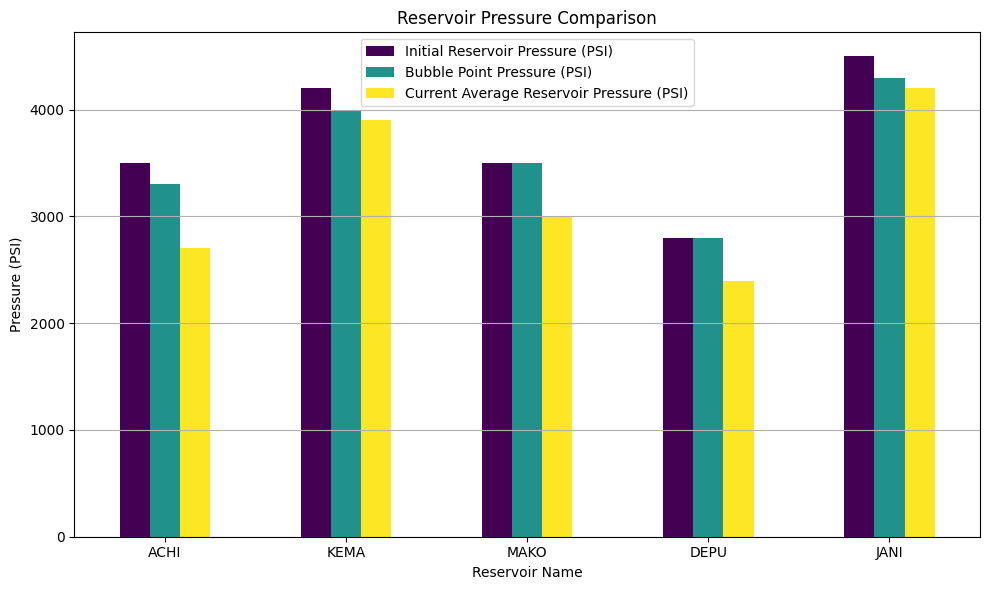

In [10]:
# Bar plot for all pressures
df.set_index('Reservoir Name')[['Initial Reservoir Pressure (PSI)', 'Bubble Point Pressure (PSI)', 'Current Average Reservoir Pressure (PSI)']].plot(
    kind='bar', figsize=(10, 6), colormap='viridis'
)
plt.title('Reservoir Pressure Comparison')
plt.ylabel('Pressure (PSI)')
plt.xticks(rotation=0)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

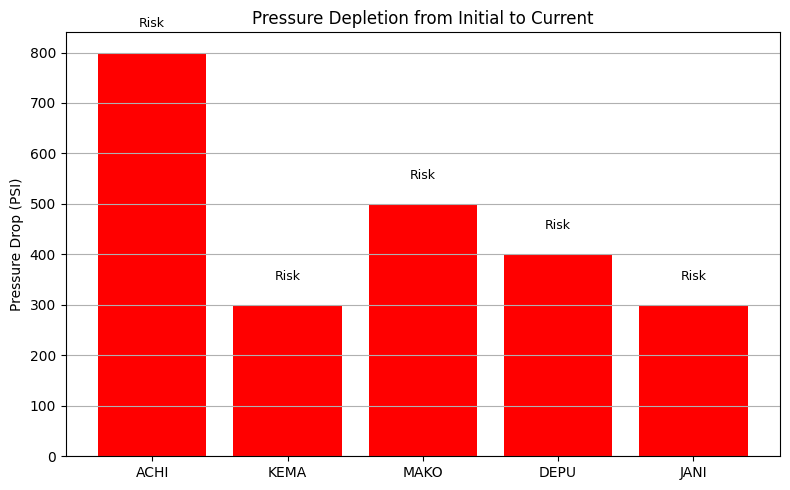

In [11]:
df['Pressure Drop'] = df['Initial Reservoir Pressure (PSI)'] - df['Current Average Reservoir Pressure (PSI)']
df['Below Bubble Point'] = df['Current Average Reservoir Pressure (PSI)'] < df['Bubble Point Pressure (PSI)']

plt.figure(figsize=(8, 5))
bars = plt.bar(df['Reservoir Name'], df['Pressure Drop'], color=df['Below Bubble Point'].map({True: 'red', False: 'green'}))
plt.title('Pressure Depletion from Initial to Current')
plt.ylabel('Pressure Drop (PSI)')
plt.grid(axis='y')

# Highlight reservoirs at risk
for bar, risk in zip(bars, df['Below Bubble Point']):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
             'Risk' if risk else 'Safe', ha='center', color='black', fontsize=9)

plt.tight_layout()
plt.show()


In [12]:
df

,Reservoir Name,Initial Reservoir Pressure (PSI),Bubble Point Pressure (PSI),Current Average Reservoir Pressure (PSI),Solution Gas-Oil-Ratio (SCF/BBL),Formation Volume Factor (RB/STB),Pressure Drop,Below Bubble Point
0,ACHI,3500,3300,2700,800,1.20,800,True
1,KEMA,4200,4000,3900,600,1.45,300,True
2,MAKO,3500,3500,3000,500,1.15,500,True
3,DEPU,2800,2800,2400,1200,1.37,400,True
4,JANI,4500,4300,4200,1000,1.30,300,True


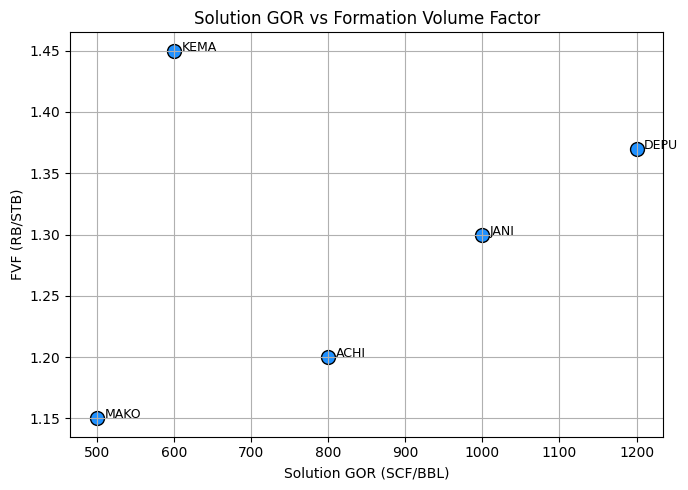

In [13]:
plt.figure(figsize=(7, 5))
plt.scatter(df['Solution Gas-Oil-Ratio (SCF/BBL)'], df['Formation Volume Factor (RB/STB)'], s=100, c='dodgerblue', edgecolors='black')

for i in range(len(df)):
    plt.text(df['Solution Gas-Oil-Ratio (SCF/BBL)'][i] + 10, df['Formation Volume Factor (RB/STB)'][i], df['Reservoir Name'][i], fontsize=9)

plt.title('Solution GOR vs Formation Volume Factor')
plt.xlabel('Solution GOR (SCF/BBL)')
plt.ylabel('FVF (RB/STB)')
plt.grid(True)
plt.tight_layout()
plt.show()